In [1]:
# Este código treina um autoencoder sem regularização
import rede_neural
import leitor_imagem
import lightning as L
import torch.nn as nn
#import matplotlib.pyplot as plt
import torch

# Carregando os dados
imagem, shape, n_pixels = leitor_imagem.read_image("imagem.png")

In [2]:
print(torch.cuda.is_available())

True


In [3]:
imagem = imagem.reshape(1, -1)
imagem.shape

(1, 25600)

In [4]:
# Treinando a rede neural:
NUM_EPOCHS = 500
treinador = L.Trainer(max_epochs=NUM_EPOCHS, accelerator="gpu", devices=1)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/vitor25023/miniconda3/envs/projeto/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [5]:
arquitetura = [n_pixels, 17800, 8900]

In [6]:
autoencoder = rede_neural.Autoencoder(arquitetura, nn.Sigmoid(), nn.MSELoss())
dm = rede_neural.DataModule(imagem)

treinador.fit(autoencoder, dm)

[25600, 17800, 8900]
[8900, 17800, 25600]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name      | Type       | Params | Mode  | FLOPs
---------------------------------------------------------
0 | camadas   | Sequential | 1.2 B  | train | 0    
1 | fun_perda | MSELoss    | 0      | train | 0    
---------------------------------------------------------
1.2 B     Trainable params
0         Non-trainable params
1.2 B     Total params
4,913.014 Total estimated model p

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x8900 and 25600x17800)

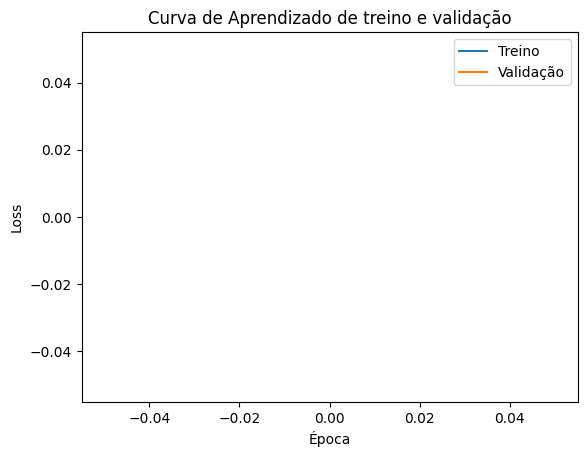

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
# Plotando curva de aprendizado
ca_treino = autoencoder.curva_aprendizado_treino
ca_val = autoencoder.curva_aprendizado_val

plt.title("Curva de Aprendizado de treino e validação")
plt.ylabel("Loss")
plt.xlabel("Época")
plt.plot(ca_treino, label="Treino")
plt.plot(ca_val, label="Validação")
plt.legend()
plt.show()
plt.savefig("Autoencoder_incompleto.png")